## 完全混合集団ゲーム と 格子上ゲームでの進化動学 比較

戦略：
- C: 協力
- D: 非協力

ゲームの利得行列：
|       | C      | D      |
|-------|--------|--------|
| C     | (5, 5) | (0, 6) |
| D     | (6, 0) | (1, 1) |

モデル：
- 完全混合集団モデル：集団全体の戦略確率によって期待利得が決まる。
- 格子上ゲーム：個体が格子上に配置され、近隣の個体とゲームを行う。戦略は近隣の戦略に影響される。

In [463]:
import random
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [464]:
class Agent:
    """
    エージェントクラス：

    """
    def __init__(self, strgSet: list, payMatrix: list):
        # 戦略の集合
        self.strgSet = strgSet
        # 初期戦略をランダムに選択
        self.strategy = random.choice(self.strgSet)
        # 次の戦略への遷移確率
        self.switchingRate = None
        # 利得行列
        self.payMatrix = payMatrix
        # 期待利得
        self.reset_expPayOff()

    # 期待利得のリセット処理
    def reset_expPayOff(self):
        self.expPayOff = {strg: 0 for strg in self.strgSet}

    # 期待利得の計算
    def calc_expPayOff(self, opp_agents: list):
        # opp_agent の戦略の割合を計算
        strg_rate = {strg: 0 for strg in self.strgSet}
        for agent in opp_agents:
            strg_rate[agent.strategy] += 1 / len(opp_agents)
        
        # 期待利得を計算
        for strg in self.strgSet: # 自分の戦略
            for opp_strg in self.strgSet: # 相手の戦略
                self.expPayOff[strg] += self.payMatrix[strg][opp_strg] * strg_rate[opp_strg]

    def IoS(self, opp_agents: list, expPayAdd: float=0.0):
        """
        計算式

        戦略 i から戦略 j に変更する確率：
        P(i → j) = 戦略 j を持つ人の割合 * (戦略 j の期待利得 + 補正値) / (利得行列の最大値 + 補正値)
        """
        # 利得行列の最大値
        maxPay = max(
            value
            for row in self.payMatrix.values()
            for value in row.values()
        )

        # スイッチングレートの初期化
        self.switchingRate = {strg: 0 for strg in self.strgSet}

        # スイッチングレートのリスト
        switching_rates = []
        
        # 現在とは異なる戦略の中から、次の戦略への遷移確立を計算
        for i, to_strg in enumerate([strg for strg in self.strgSet if strg != self.strategy]):
            # 戦略 to_strg を持つ人の割合
            strg_rate = sum(1 for agent in opp_agents if agent.strategy == to_strg) / len(opp_agents)
            
            # 遷移確率を計算
            switching_rates.append(strg_rate * (self.expPayOff[to_strg] + expPayAdd) / (maxPay + expPayAdd))

            self.switchingRate[to_strg] = switching_rates[-1]
        
        # そのまま残る確率を計算
        self.switchingRate[self.strategy] = 1 - sum(switching_rates)
            
    # 戦略の更新
    def update_strategy(self):
        # スイッチングレートに基づいて次の戦略を選択
        self.strategy = random.choices(
            list(self.switchingRate.keys()),
            weights=list(self.switchingRate.values()),
            k=1
        )[0]

In [465]:
# テスト (calc_expPayOff)
strgSet = ["C", "D"]

payMatrix = {
    "C": {"C": 5, "D": 0},
    "D": {"C": 6, "D": 1}
}

agent_list = [Agent(strgSet, payMatrix) for _ in range(10)]
for agent in agent_list:
    agent.calc_expPayOff(agent_list)

expPayOff_list = [agent.expPayOff for agent in agent_list]
print(expPayOff_list)

[{'C': 1.5000000000000002, 'D': 2.5}, {'C': 1.5000000000000002, 'D': 2.5}, {'C': 1.5000000000000002, 'D': 2.5}, {'C': 1.5000000000000002, 'D': 2.5}, {'C': 1.5000000000000002, 'D': 2.5}, {'C': 1.5000000000000002, 'D': 2.5}, {'C': 1.5000000000000002, 'D': 2.5}, {'C': 1.5000000000000002, 'D': 2.5}, {'C': 1.5000000000000002, 'D': 2.5}, {'C': 1.5000000000000002, 'D': 2.5}]


In [466]:
class Game:
    def __init__(self, strgSet: list, payMatrix: list, L: int=50):
        self.L = L
        self.agent_list = [[Agent(strgSet, payMatrix) for _ in range(L)] for _ in range(L)]

    # エージェントの期待利得をリセットする
    def reset(self):
        for l in self.agent_list:
            for agent in l:
                agent.reset_expPayOff()
    
    # エージェントの期待利得とスイッチングレートを計算する
    def expFn(self):
        for i, l in enumerate(self.agent_list):
            for j, agent in enumerate(l):

                # 周囲（4近傍）のエージェントを取得
                opp_agents = []
                # 上
                opp_agents.append(self.agent_list[i-1][j])
                # 下
                opp_agents.append(self.agent_list[i+1-self.L][j])
                # 左
                opp_agents.append(self.agent_list[i][j-1])
                # 右
                opp_agents.append(self.agent_list[i][j+1-self.L])

                # 期待利得の計算
                agent.calc_expPayOff(opp_agents)

                # スイッチングレートの計算
                agent.IoS(opp_agents)
    
    # エージェントの戦略を更新する
    def update_strategy(self):
        for l in self.agent_list:
            for agent in l:
                agent.update_strategy()
                

def calc_C_ratio(agent_list: list):
    total_agents = sum(len(l) for l in agent_list)
    C_count = sum(agent.strategy == "C" for l in agent_list for agent in l)
    return C_count / total_agents

In [467]:
# テスト (Game)
strgSet = ["C", "D"]
payMatrix = {
    "C": {"C": 5, "D": 0},
    "D": {"C": 6, "D": 1}
}

game = Game(strgSet, payMatrix, L=20)
game.reset()
print("C_RATE (init):", calc_C_ratio(game.agent_list))
game.expFn()
game.update_strategy()
print("C_RATE (play1):", calc_C_ratio(game.agent_list))

C_RATE (init): 0.4875
C_RATE (play1): 0.4575


In [468]:
def simulate_game(strgSet: list, payMatrix: list, L: int=50, rounds: int=100):
    game = Game(strgSet, payMatrix, L)
    C_ratios = [calc_C_ratio(game.agent_list)]
    
    for _ in range(rounds):
        game.reset()
        game.expFn()
        game.update_strategy()
        C_ratios.append(calc_C_ratio(game.agent_list))
    
    return C_ratios

def plot_C_ratios(C_ratios: list):
    plt.ylim(0, 1)
    plt.xlabel("Round")
    plt.ylabel("C Ratio")
    plt.title("C Ratio Over Time")
    plt.grid()
    plt.plot(C_ratios)
    plt.show()

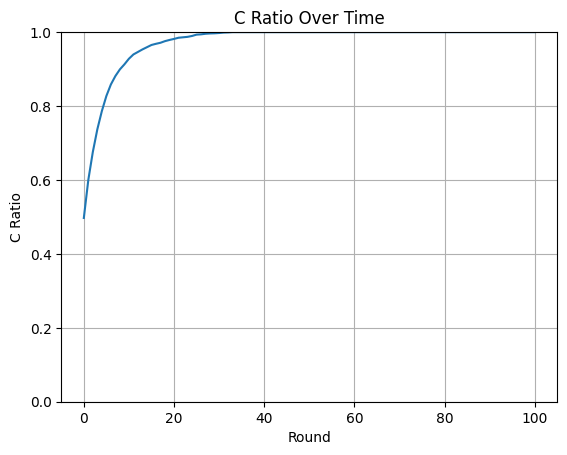

In [469]:
# シミュレーションの実行
strgSet = ["C", "D"]
payMatrix = {
    "C": {"C": 3, "D": -1},
    "D": {"C": -1, "D": 1}
}
C_ratios = simulate_game(strgSet, payMatrix, L=50, rounds=100)
# C_ratios をプロット
plot_C_ratios(C_ratios)

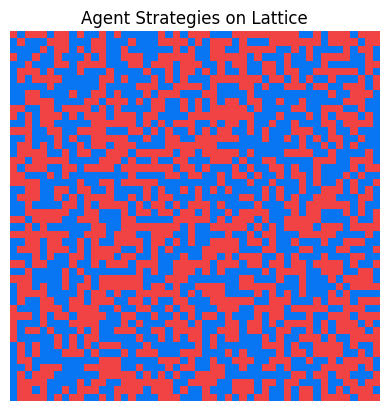

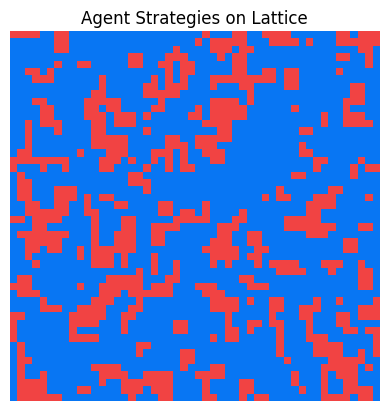

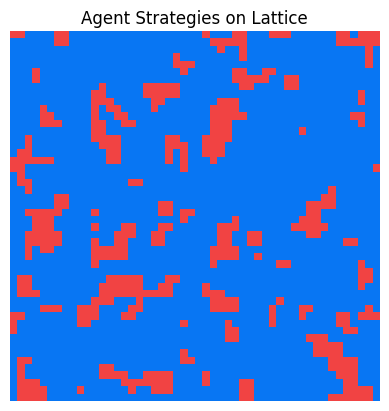

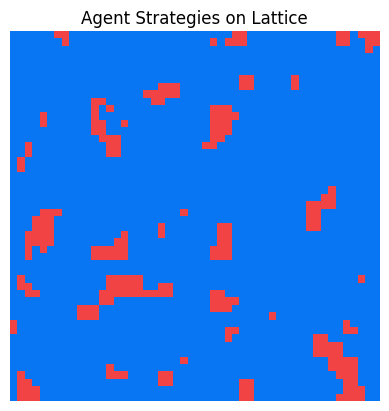

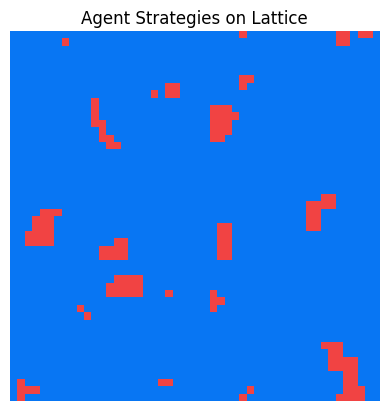

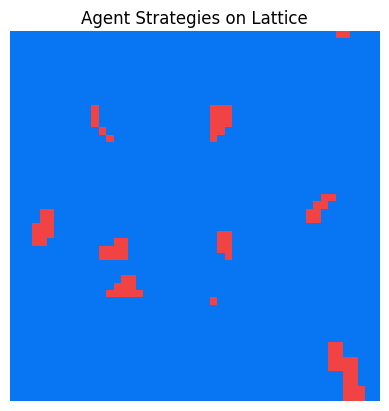

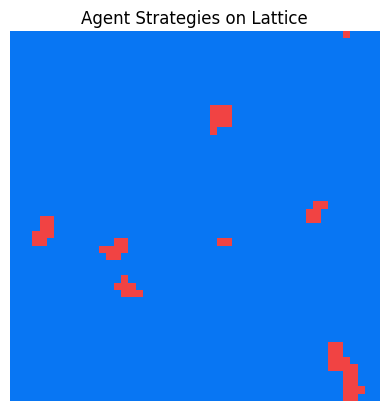

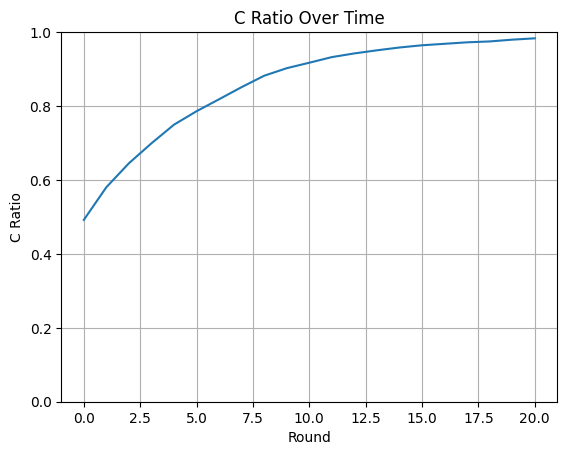

In [470]:
def plot_lattice(agent_list: list):
    strategy_map = {"C": 0, "D": 1}
    lattice = [[strategy_map[agent.strategy] for agent in l] for l in agent_list]
    soft_cmap = ListedColormap(["#0876f3", "#f14343"])
    
    plt.imshow(lattice, cmap=soft_cmap, vmin=0, vmax=1)
    plt.title("Agent Strategies on Lattice")
    plt.axis("off")
    plt.show()

def simulate_game(strgSet: list, payMatrix: list, L: int=50, rounds: int=100, split_n: int=2):
    game = Game(strgSet, payMatrix, L)
    C_ratios = [calc_C_ratio(game.agent_list)]
    
    plot_lattice(game.agent_list)  # 初期状態のプロット

    for round in range(rounds):
        game.reset()
        game.expFn()
        game.update_strategy()
        C_ratios.append(calc_C_ratio(game.agent_list))
        
        # split_n ラウンドごとに格子をプロット
        if (round + 1) % split_n == 0:
            plot_lattice(game.agent_list)
    return C_ratios

# シミュレーションの実行
strgSet = ["C", "D"]
payMatrix = {
    "C": {"C": 3, "D": -1},
    "D": {"C": -1, "D": 1}
}
C_ratios = simulate_game(strgSet, payMatrix, L=50, rounds=20, split_n=3)
# C_ratios をプロット
plot_C_ratios(C_ratios)